In [ ]:

# Import required libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:

# Load the dataset
possible_paths = [
    "brca.csv",
    "./brca.csv",
    "/mnt/data/brca.csv"
]

data_path = next((path for path in possible_paths if os.path.exists(path)), None)

if data_path is None:
    raise FileNotFoundError(
        "brca.csv was not found. Place the CSV file in the same folder as this notebook."
    )

df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset loaded from: brca.csv
Dataset shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,x.radius_se,x.texture_se,x.perimeter_se,x.area_se,x.smoothness_se,x.compactness_se,x.concavity_se,x.concave_pts_se,x.symmetry_se,x.fractal_dim_se,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.5400,14.3600,87.4600,566.3000,0.0978,0.0813,0.0666,0.0478,0.1885,0.0577,0.2699,0.7886,2.0580,23.5600,0.0085,0.0146,0.0239,0.0132,0.0198,0.0023,15.1100,19.2600,99.7000,711.2000,0.1440,0.1773,0.2390,0.1288,0.2977,0.0726,B
1,2,13.0800,15.7100,85.6300,520.0000,0.1075,0.1270,0.0457,0.0311,0.1967,0.0681,0.1852,0.7477,1.3830,14.6700,0.0041,0.0190,0.0170,0.0065,0.0168,0.0024,14.5000,20.4900,96.0900,630.5000,0.1312,0.2776,0.1890,0.0728,0.3184,0.0818,B
2,3,9.5040,12.4400,60.3400,273.9000,0.1024,0.0649,0.0296,0.0208,0.1815,0.0691,0.2773,0.9768,1.9090,15.7000,0.0096,0.0143,0.0198,0.0142,0.0203,0.0030,10.2300,15.6600,65.1300,314.9000,0.1324,0.1148,0.0887,0.0623,0.2450,0.0777,B
3,4,13.0300,18.4200,82.6100,523.8000,0.0898,0.0377,0.0256,0.0292,0.1467,0.0586,0.1839,2.3420,1.1700,14.1600,0.0044,0.0049,0.0134,0.0116,0.0267,0.0018,13.3000,22.8100,84.4600,545.9000,0.0970,0.0462,0.0483,0.0501,0.1987,0.0617,B
4,5,8.1960,16.8400,51.7100,201.9000,0.0860,0.0594,0.0159,0.0059,0.1769,0.0650,0.1563,0.9567,1.0940,8.2050,0.0090,0.0165,0.0159,0.0059,0.0257,0.0026,8.9640,21.9600,57.2600,242.2000,0.1297,0.1357,0.0688,0.0256,0.3105,0.0741,B


In [ ]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())


Number of rows: 569
Number of columns: 32

Column names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


In [ ]:

# Display data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [ ]:

# Statistical summary of numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,569.0000,285.0000,164.4004,1.0000,143.0000,285.0000,427.0000,569.0000
x.radius_mean,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
x.texture_mean,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
x.perimeter_mean,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
x.area_mean,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
x.smoothness_mean,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
x.compactness_mean,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
x.concavity_mean,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
x.concave_pts_mean,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
x.symmetry_mean,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040


In [ ]:

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Check missing values
missing_values = df.isnull().sum()
missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (missing_values.values / len(df)) * 100
})

missing_table[missing_table["Missing Values"] > 0]


Number of duplicate rows: 0


,Column,Missing Values,Missing Percentage


In [ ]:

# Display class distribution
print("Target class counts:")
print(df["y"].value_counts())

print("\nTarget class percentages:")
print((df["y"].value_counts(normalize=True) * 100).round(2))


Target class counts:
y
B    357
M    212
Name: count, dtype: int64

Target class percentages:
y
B   62.7400
M   37.2600
Name: proportion, dtype: float64


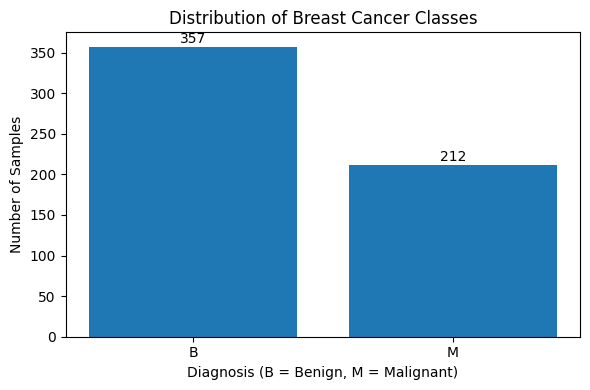

In [ ]:

# Plot target class distribution
class_counts = df["y"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribution of Breast Cancer Classes")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Number of Samples")

for i, value in enumerate(class_counts.values):
    plt.text(i, value + 5, str(value), ha="center")

plt.tight_layout()
plt.show()


In [ ]:

# Create a clean copy
data = df.copy()

# Remove identifier column if present
if "Unnamed: 0" in data.columns:
    data.drop(columns=["Unnamed: 0"], inplace=True)

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Handle missing values if any exist
# Numerical columns are filled with their median.
numerical_columns = data.select_dtypes(include=np.number).columns
data[numerical_columns] = data[numerical_columns].fillna(
    data[numerical_columns].median()
)

# Encode target: B = 0, M = 1
target_mapping = {"B": 0, "M": 1}
data["y"] = data["y"].map(target_mapping)

if data["y"].isnull().any():
    raise ValueError("Unexpected target values were found in column 'y'.")

print("Cleaned dataset shape:", data.shape)
print("\nEncoded target distribution:")
print(data["y"].value_counts().rename(index={0: "Benign (0)", 1: "Malignant (1)"}))


Cleaned dataset shape: (569, 31)

Encoded target distribution:
y
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


In [ ]:

# Separate independent variables and target variable
X = data.drop(columns=["y"])
y = data["y"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of input features:", X.shape[1])


Feature matrix shape: (569, 30)
Target vector shape: (569,)
Number of input features: 30


In [ ]:

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())


Training feature shape: (455, 30)
Testing feature shape: (114, 30)

Training target distribution:
y
0   0.6264
1   0.3736
Name: proportion, dtype: float64

Testing target distribution:
y
0   0.6316
1   0.3684
Name: proportion, dtype: float64


In [ ]:

# Create and train the Logistic Regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [ ]:

# Calculate heuristic K
heuristic_k = int(np.sqrt(len(X_train)))

# Prefer an odd K for binary classification
if heuristic_k % 2 == 0:
    heuristic_k += 1

print("Number of training samples:", len(X_train))
print("Heuristic K (approximately square root of N):", heuristic_k)


Number of training samples: 455
Heuristic K (approximately square root of N): 21


In [ ]:

# Tune K using 5-fold cross-validation
k_values = list(range(1, 32, 2))
cv_scores = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_scores.append(scores.mean())

k_results = pd.DataFrame({
    "K": k_values,
    "Mean CV Accuracy": cv_scores
})

best_k = int(k_results.loc[k_results["Mean CV Accuracy"].idxmax(), "K"])

print("Best K selected using cross-validation:", best_k)
k_results


Best K selected using cross-validation: 7


,K,Mean CV Accuracy
0,1,0.9473
1,3,0.9670
2,5,0.9626
3,7,0.9692
4,9,0.9670
5,11,0.9582
6,13,0.9604
7,15,0.9604
8,17,0.9604
9,19,0.9582


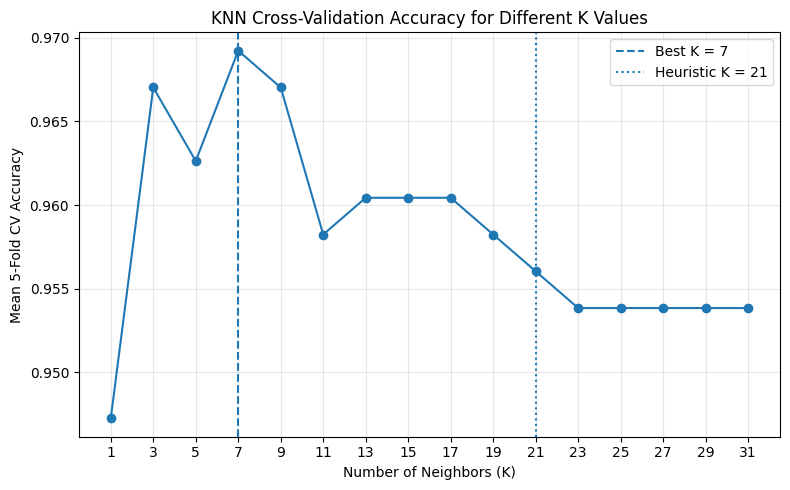

In [ ]:

# Plot cross-validation accuracy for different K values
plt.figure(figsize=(8, 5))
plt.plot(k_results["K"], k_results["Mean CV Accuracy"], marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best K = {best_k}")
plt.axvline(heuristic_k, linestyle=":", label=f"Heuristic K = {heuristic_k}")
plt.title("KNN Cross-Validation Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean 5-Fold CV Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# Create and train the KNN pipeline using the selected K
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform",
        metric="minkowski",
        p=2
    ))
])

knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

print(f"KNN model trained successfully using K = {best_k}.")


KNN model trained successfully using K = 7.


In [ ]:

def calculate_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

logistic_metrics = calculate_metrics(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

knn_metrics = calculate_metrics(
    f"KNN (K={best_k})",
    y_test,
    y_pred_knn
)

comparison_df = pd.DataFrame([logistic_metrics, knn_metrics])
comparison_df.set_index("Model")


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512
KNN (K=7),0.9561,0.9744,0.9048,0.9383


In [ ]:

print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Benign", "Malignant"],
    digits=4
))

print("KNN CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Benign", "Malignant"],
    digits=4
))


LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114

KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9467    0.9861    0.9660        72
   Malignant     0.9744    0.9048    0.9383        42

    accuracy                         0.9561       114
   macro avg     0.9605    0.9454    0.9521       114
weighted avg     0.9569    0.9561    0.9558       114



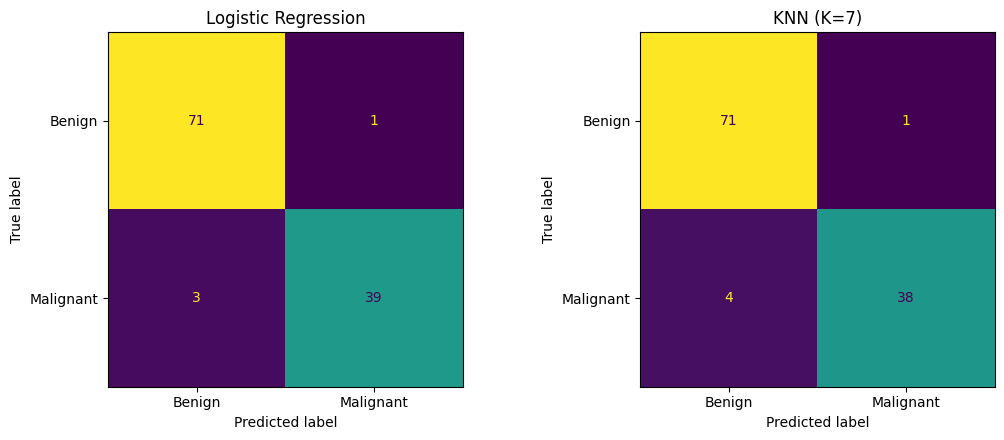

In [ ]:

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_logistic),
    display_labels=["Benign", "Malignant"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_knn),
    display_labels=["Benign", "Malignant"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title(f"KNN (K={best_k})")

plt.tight_layout()
plt.show()


In [ ]:

# Display confusion-matrix values explicitly
log_cm = confusion_matrix(y_test, y_pred_logistic)
knn_cm = confusion_matrix(y_test, y_pred_knn)

confusion_values = pd.DataFrame({
    "Model": ["Logistic Regression", f"KNN (K={best_k})"],
    "True Negative": [log_cm[0, 0], knn_cm[0, 0]],
    "False Positive": [log_cm[0, 1], knn_cm[0, 1]],
    "False Negative": [log_cm[1, 0], knn_cm[1, 0]],
    "True Positive": [log_cm[1, 1], knn_cm[1, 1]]
})

confusion_values.set_index("Model")


,True Negative,False Positive,False Negative,True Positive
Model,,,,
Logistic Regression,71,1,3,39
KNN (K=7),71,1,4,38



## 8. Performance Comparison


In [ ]:

formatted_comparison = comparison_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    formatted_comparison[column] = (
        formatted_comparison[column] * 100
    ).round(2).astype(str) + "%"

formatted_comparison.set_index("Model")


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,96.49%,97.5%,92.86%,95.12%
KNN (K=7),95.61%,97.44%,90.48%,93.83%


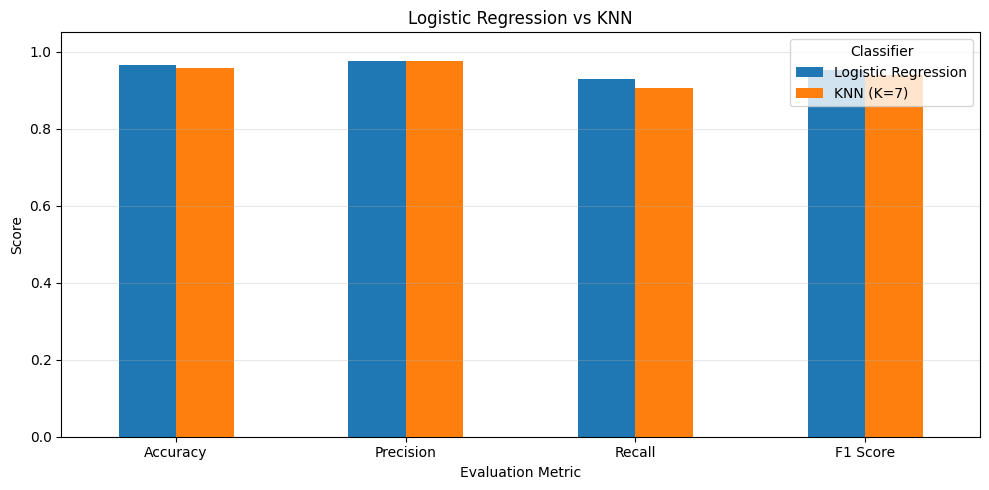

In [ ]:

# Plot model metric comparison
plot_df = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].T

ax = plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Logistic Regression vs KNN")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Classifier")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


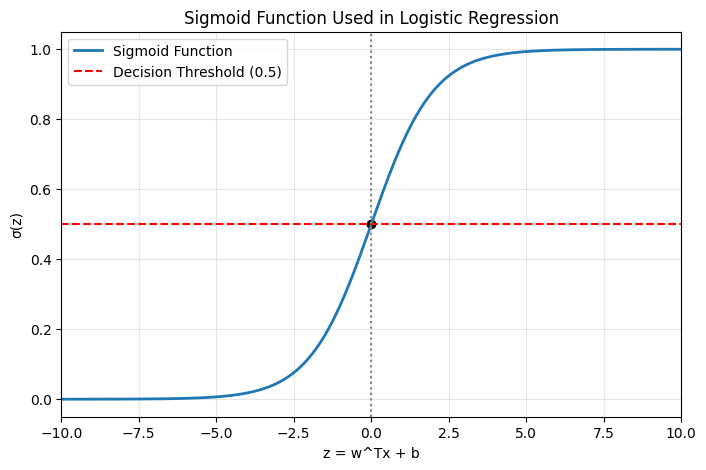

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z=np.linspace(-10,10,400)
y=1/(1+np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z,y,label='Sigmoid Function',linewidth=2)
plt.axhline(0.5,color='red',linestyle='--',label='Decision Threshold (0.5)')
plt.axvline(0,color='gray',linestyle=':')
plt.scatter([0],[0.5],color='black')
plt.title('Sigmoid Function Used in Logistic Regression')
plt.xlabel('z = w^Tx + b')
plt.ylabel('σ(z)')
plt.xlim(-10,10)
plt.ylim(-0.05,1.05)
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()


## 9.  Interpretation
Best average score across the four metrics: Logistic Regression
Highest test accuracy: Logistic Regression
Highest malignant-class recall: Logistic Regression
Highest malignant-class F1-score: Logistic Regression

Logistic Regression detected a greater proportion of malignant cases on this test split.

In medical diagnosis, recall for the malignant class is particularly important because a false negative may leave a malignant case undetected.
